# This project builds an ML pipeline for petrophysical characterization and representative model selection using Kansas well logs. The workflow reduces uncertainty quantification ensemble by about 85%, enhances reservoir volumetric computation, and  supports faster reservoir development decisions 

### Work progression: build accurate petrophysical models from well logs → generate ensemble → select representative models → quantify uncertainty reduction.

## 1. Import needed libraries / dependencies

In [107]:
import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load the data and clean

In [108]:
las = lasio.read('https://kgsimages.blob.core.windows.net/web/web_1/WebDocs/WellLogs/kcc_logs_2025/1056890332.las')
df = las.df()
df.head()

,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI
DEPT,,,,,,,,,,,,,,,,,,
244.0,69.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244.5,71.686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245.0,75.918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245.5,80.436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246.0,76.796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6073 entries, 244.0 to 3280.0
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GR      5941 non-null   float64
 1   CALY    5805 non-null   float64
 2   CALM    5810 non-null   float64
 3   CALX    5816 non-null   float64
 4   SP      5943 non-null   float64
 5   TENS    5942 non-null   float64
 6   BS      5918 non-null   float64
 7   SFL     5938 non-null   float64
 8   ILD     5944 non-null   float64
 9   ILM     5916 non-null   float64
 10  DPHI    5950 non-null   float64
 11  NPHI    5818 non-null   float64
 12  PE      5948 non-null   float64
 13  MINV    5936 non-null   float64
 14  MNOR    5936 non-null   float64
 15  DRHO    5946 non-null   float64
 16  DT      5946 non-null   float64
 17  SPHI    5946 non-null   float64
dtypes: float64(18)
memory usage: 901.5 KB


In [110]:
# rearrange the dataframe and make depth a distinct column.
# ALso correct spelling from DEPT to Depth

df = df.reset_index()
df= df.rename(columns={'DEPT':'DEPTH'})
df.head()

,DEPTH,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI
0,244.0,69.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,244.5,71.686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,245.0,75.918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,245.5,80.436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,246.0,76.796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
# drop nulls in the column of interest (GR, NPHI, DPHI, ILD, CALM)
df = df.dropna(subset = ['GR', 'NPHI', 'DPHI', 'ILD', 'CALM'])
df.head()

,DEPTH,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI
191,339.5,97.759,8.915,8.112,9.482,33.252,1792.279,7.873,30.719,24.408,25.642,19.270,29.258,2.559,11.374,14.021,0.015,119.483,29.946
192,340.0,107.505,8.943,8.186,9.527,33.485,1813.362,7.873,28.734,22.865,23.331,18.986,29.006,2.781,11.244,12.614,0.002,121.717,29.946
193,340.5,115.464,8.938,8.220,9.536,34.530,1825.388,7.873,28.568,21.419,21.320,19.554,29.977,2.746,11.118,12.459,-0.008,124.449,29.947
194,341.0,119.610,8.929,8.226,9.574,35.577,1829.193,7.873,27.998,20.066,19.482,19.866,29.971,2.701,10.818,12.199,-0.011,128.074,29.947
195,341.5,127.681,8.920,8.231,9.633,36.481,1832.998,7.873,25.849,18.798,17.801,20.276,29.965,2.655,9.918,11.179,-0.010,130.821,29.947


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5750 entries, 191 to 5940
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DEPTH   5750 non-null   float64
 1   GR      5750 non-null   float64
 2   CALY    5750 non-null   float64
 3   CALM    5750 non-null   float64
 4   CALX    5750 non-null   float64
 5   SP      5750 non-null   float64
 6   TENS    5750 non-null   float64
 7   BS      5750 non-null   float64
 8   SFL     5750 non-null   float64
 9   ILD     5750 non-null   float64
 10  ILM     5750 non-null   float64
 11  DPHI    5750 non-null   float64
 12  NPHI    5750 non-null   float64
 13  PE      5750 non-null   float64
 14  MINV    5750 non-null   float64
 15  MNOR    5750 non-null   float64
 16  DRHO    5750 non-null   float64
 17  DT      5750 non-null   float64
 18  SPHI    5750 non-null   float64
dtypes: float64(19)
memory usage: 898.4 KB


## 3. Delve into advanced petrophysical processing

### 3a. Calculate volume of shale

In [113]:
# Compute Shale volume, Vsh, using the simple linear method  (simple linear GR method - common in petrophysics)
gr_min  = df['GR'].quantile(0.05) #This represents the gamma ray value for clean sand reservoir
gr_max = df['GR'].quantile(0.95) # This represents the gamma ray value for a shale lithology
df['VSH'] = (df['GR'] - gr_min) / (gr_max - gr_min)
df['VSH'] = df['VSH'].clip(0, 1) # The clip metod is applied to ensure the computed Vshale falls between 0 and 1

In [114]:
df.head()

,DEPTH,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI,VSH
191,339.5,97.759,8.915,8.112,9.482,33.252,1792.279,7.873,30.719,24.408,25.642,19.270,29.258,2.559,11.374,14.021,0.015,119.483,29.946,0.680464
192,340.0,107.505,8.943,8.186,9.527,33.485,1813.362,7.873,28.734,22.865,23.331,18.986,29.006,2.781,11.244,12.614,0.002,121.717,29.946,0.758471
193,340.5,115.464,8.938,8.220,9.536,34.530,1825.388,7.873,28.568,21.419,21.320,19.554,29.977,2.746,11.118,12.459,-0.008,124.449,29.947,0.822175
194,341.0,119.610,8.929,8.226,9.574,35.577,1829.193,7.873,27.998,20.066,19.482,19.866,29.971,2.701,10.818,12.199,-0.011,128.074,29.947,0.855359
195,341.5,127.681,8.920,8.231,9.633,36.481,1832.998,7.873,25.849,18.798,17.801,20.276,29.965,2.655,9.918,11.179,-0.010,130.821,29.947,0.919960


### 3b. Calculate effective porosity by averaging density and neutron porosity after correcting for shale volume

In [115]:
# 2.2 Effective porosity (average of density + neutron, shale-corrected)
df['PHI'] = ((df['DPHI'] + df['NPHI']) / 2) * (1 - df['VSH'])
df['PHI'] = df['PHI'].clip(0, 0.45)   # clip porosity value between 0 and 45% to make it realistic
df['PHI'].nunique()

164

### 3c. Feature Engineering for ML 

In [116]:
# To select the features that will be used for the machine learning aspect

df['PHID_NPHID'] = df['DPHI'] - df['NPHI']   # crossover indicator
df['RHOB_proxy'] = 2.65 - (2.65 - 1.0) * df['PHI']  # a synthetic bulk density log

print(df[['DEPTH', 'PHI', 'VSH']].describe())

             DEPTH          PHI          VSH
count  5750.000000  5750.000000  5750.000000
mean   1776.750000     0.401462     0.499138
std     830.013178     0.136296     0.334639
min     339.500000     0.000000     0.000000
25%    1058.125000     0.450000     0.136187
50%    1776.750000     0.450000     0.572919
75%    2495.375000     0.450000     0.789405
max    3214.000000     0.450000     1.000000


In [117]:
df

,DEPTH,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,...,PE,MINV,MNOR,DRHO,DT,SPHI,VSH,PHI,PHID_NPHID,RHOB_proxy
191,339.5,97.759,8.915,8.112,9.482,33.252,1792.279,7.873,30.719,24.408,...,2.559,11.374,14.021,0.015,119.483,29.946,0.680464,0.45,-9.988,1.9075
192,340.0,107.505,8.943,8.186,9.527,33.485,1813.362,7.873,28.734,22.865,...,2.781,11.244,12.614,0.002,121.717,29.946,0.758471,0.45,-10.020,1.9075
193,340.5,115.464,8.938,8.220,9.536,34.530,1825.388,7.873,28.568,21.419,...,2.746,11.118,12.459,-0.008,124.449,29.947,0.822175,0.45,-10.423,1.9075
194,341.0,119.610,8.929,8.226,9.574,35.577,1829.193,7.873,27.998,20.066,...,2.701,10.818,12.199,-0.011,128.074,29.947,0.855359,0.45,-10.105,1.9075
195,341.5,127.681,8.920,8.231,9.633,36.481,1832.998,7.873,25.849,18.798,...,2.655,9.918,11.179,-0.010,130.821,29.947,0.919960,0.45,-9.689,1.9075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5936,3212.0,34.257,7.907,7.718,7.856,33.124,2557.258,7.885,23.393,12.845,...,1.673,11.859,17.039,0.016,77.684,21.302,0.172195,0.45,6.310,1.9075
5937,3212.5,36.154,7.902,7.719,7.856,31.143,2566.007,7.885,22.588,12.869,...,1.641,11.963,17.038,0.017,78.065,21.546,0.187378,0.45,5.667,1.9075
5938,3213.0,35.374,7.896,7.719,7.856,29.153,2566.007,7.885,22.588,12.893,...,1.651,11.517,17.037,0.018,78.995,22.159,0.181135,0.45,5.925,1.9075
5939,3213.5,36.468,7.891,7.720,7.856,27.162,2580.627,7.884,24.552,13.030,...,1.678,11.250,17.286,0.015,80.291,23.151,0.189892,0.45,6.372,1.9075


## 4. Rock Typing Using Unsupervised machine learning

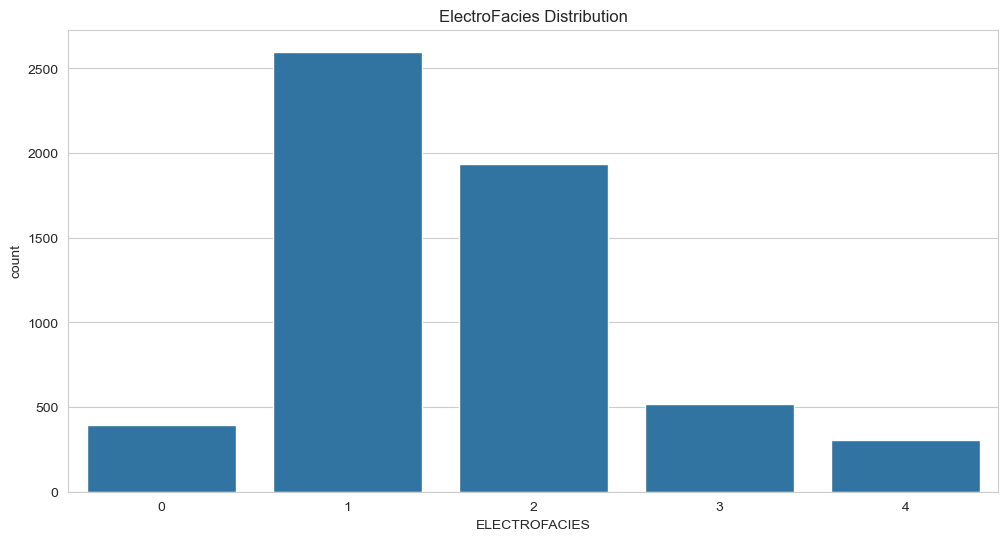

In [118]:
features_cluster = ['GR', 'DPHI', 'NPHI', 'ILD', 'PHI', 'VSH'] #These are the logs that are more critical in determinig the rock and fluid behavior of the interval being logged
X_cluster = df[features_cluster].copy()  # A new dataframe is created using these logs to ensure the original dataframe is not tampered with or modified

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)  # The log values are standardised to ensure unifmroity since the sale of measurement of each log s different

# 5 clusters is decided to be sed for my K means model, and the algorithm is selected to run 10 times and oick the best model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['ELECTROFACIES'] = kmeans.fit_predict(X_scaled)

sns.countplot(data=df, x='ELECTROFACIES')
plt.title('ElectroFacies Distribution')
plt.show()

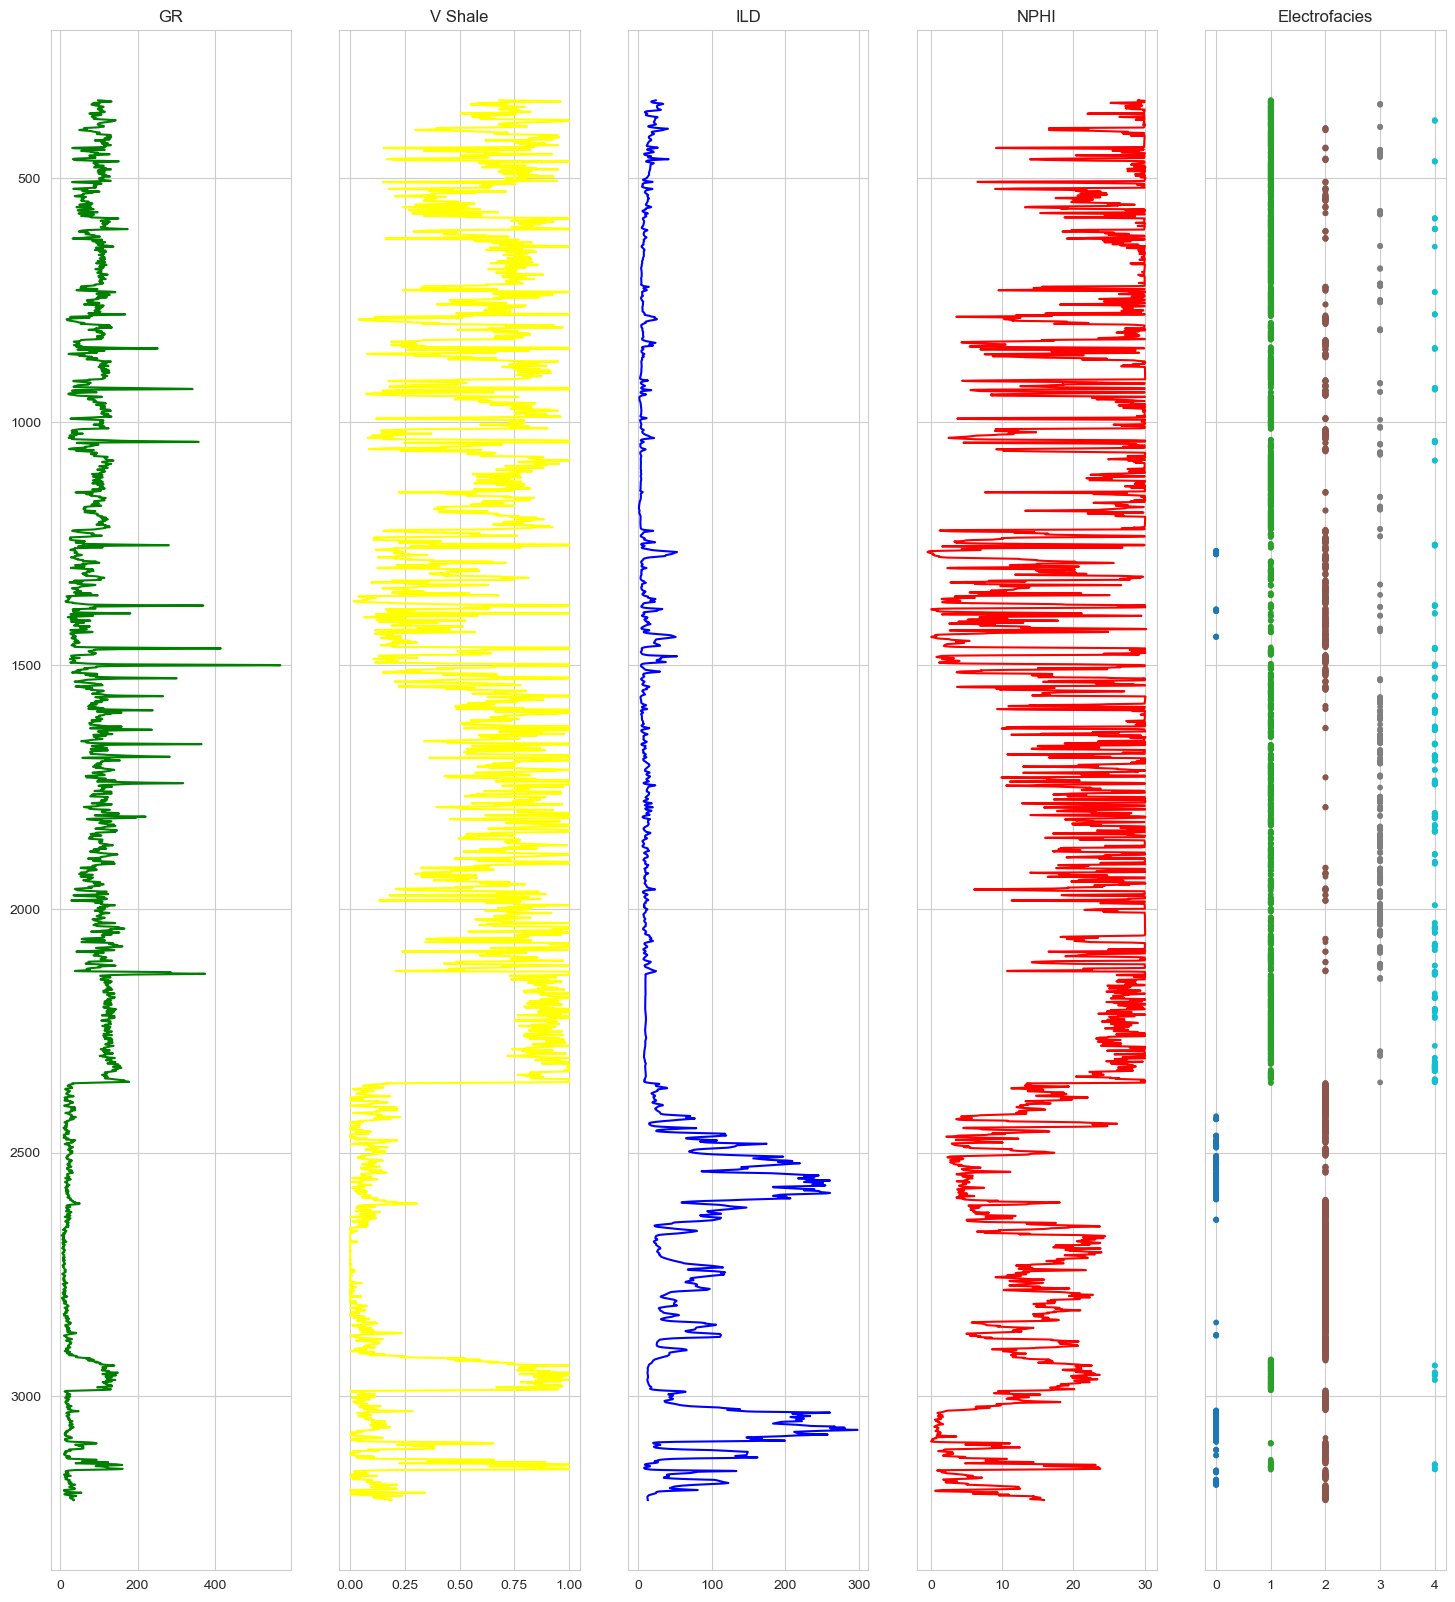

In [119]:
fig, axs = plt.subplots(1, 5, figsize=(18, 20), sharey=True) # subplots of 5 different logs
axs[0].plot(df['GR'], df['DEPTH'], color='green')
axs[0].set_title('GR')

axs[1].plot(df['VSH'], df['DEPTH'], color='yellow')
axs[1].set_title('V Shale')

axs[2].plot(df['ILD'], df['DEPTH'], color='blue')
axs[2].set_title('ILD')

axs[3].plot(df['NPHI'], df['DEPTH'], color='red')
axs[3].set_title('NPHI')


axs[4].scatter(df['ELECTROFACIES'], df['DEPTH'], c=df['ELECTROFACIES'], cmap='tab10', s=10)
axs[4].set_title('Electrofacies')
plt.gca().invert_yaxis()  # depth increases downward
plt.show()

## 5. Predicting permeability values

### 5a. Calculating permeability ( synthetic permebaility)

In [120]:
# Generate synthetic permeability (realistic Kozeny-Carman style relation + noise)
np.random.seed(42)
df['SYNTH_PERM'] = 10 ** (8 * df['PHI'] - 2.5 + np.random.normal(0, 0.8, len(df)))
df['SYNTH_PERM'] = df['SYNTH_PERM'].clip(0.01, 10000)   # mD range

### 5b. ML using XGBoost to predict permeability

In [121]:
# Train XGBoost regressor (logs + facies → permeability)
features = ['GR', 'DPHI', 'NPHI', 'ILD', 'PHI', 'VSH', 'ELECTROFACIES']
X = df[features]
y = np.log10(df['SYNTH_PERM'] + 1)   # log transform for stability

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=29)

#default parameters were used in the regressor arguments
model_perm = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
model_perm.fit(X_train, y_train)

# Predict on full well
df['PRED_PERM'] = 10 ** model_perm.predict(X) - 1
df['PRED_PERM'] = df['PRED_PERM'].clip(0.01, 10000)

print("Permeability prediction RMSE (log scale):", mean_squared_error(y_test, model_perm.predict(X_test), squared=False))

Permeability prediction RMSE (log scale): 0.6451494881136411


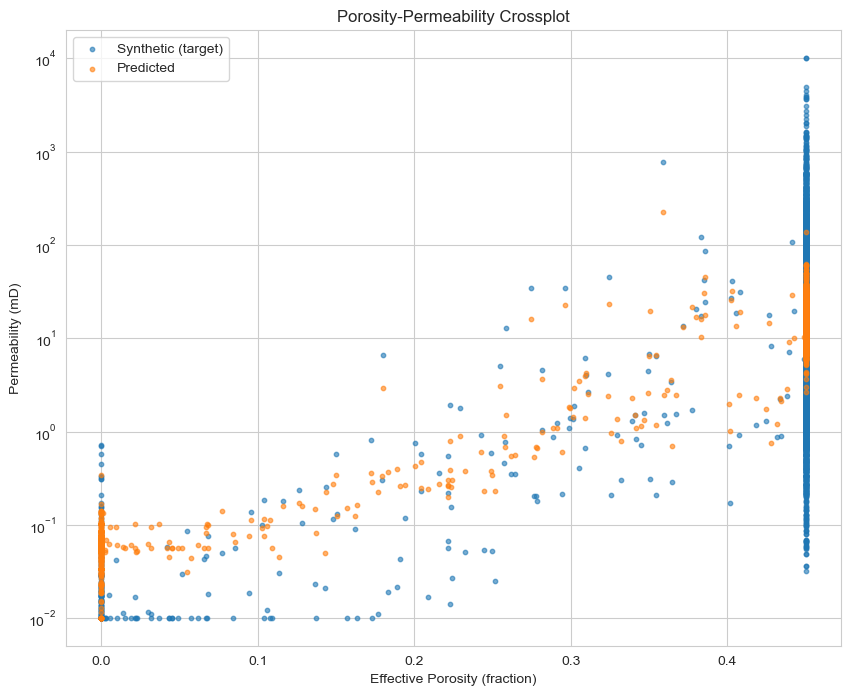

In [122]:
plt.figure(figsize=(10,8))
plt.scatter(df['PHI'], df['SYNTH_PERM'], label='Synthetic (target)', s=10, alpha=0.6)
plt.scatter(df['PHI'], df['PRED_PERM'], label='Predicted', s=10, alpha=0.6)
plt.yscale('log')
plt.xlabel('Effective Porosity (fraction)')
plt.ylabel('Permeability (mD)')
plt.title('Porosity-Permeability Crossplot')
plt.legend()
plt.show()

## 6. Generate Ensemble of Realizations (Monte Carlo)

In [130]:
# Generate Ensemble of Realizations (Monte Carlo)
n_realizations = 150
metrics_list = []

np.random.seed(42)   # keeps results reproducible

for i in range(n_realizations):
    df_real = df.copy()
    
    # Global systematic bias (affects entire well)
    bias_phi = np.random.normal(0, 0.035)                    # ±2.2 porosity units
    df_real['PHI_noisy'] = df_real['PHI'] + bias_phi
    df_real['PHI_noisy'] = df_real['PHI_noisy'].clip(0, 0.35)
    
    bias_perm_factor = np.random.lognormal(0.0, 0.28)
    df_real['PERM_noisy'] = df_real['PRED_PERM'] * bias_perm_factor
    
    # === CRITICAL: Use the NOISY columns here ===
    avg_phi = df_real['PHI_noisy'].mean()
    ntg = (df_real['PHI_noisy'] > 0.08).mean()
    pore_volume_proxy = df_real['PHI_noisy'].sum() * 0.1524
    perm_geo_mean = np.exp(np.mean(np.log(df_real['PERM_noisy'] + 1e-6)))
    
    metrics_list.append([avg_phi, ntg, pore_volume_proxy, perm_geo_mean])

metrics_df = pd.DataFrame(metrics_list, columns=['Avg_PHI', 'NTG', 'PoreVol_Proxy', 'Perm_GeoMean'])

# === DIAGNOSTIC (must see big variation now) ===
print("=== VARIATION CHECK ===")
print(metrics_df['PoreVol_Proxy'].describe())
print(f"Relative std of PoreVol_Proxy: {(metrics_df['PoreVol_Proxy'].std() / metrics_df['PoreVol_Proxy'].mean() * 100):.2f} %")
print("\nFirst 5 PoreVol_Proxy values:", metrics_df['PoreVol_Proxy'].head().values)

=== VARIATION CHECK ===
count    150.000000
mean     275.508935
std        2.399019
min      262.140322
25%      274.117211
50%      274.609235
75%      276.387906
max      282.577839
Name: PoreVol_Proxy, dtype: float64
Relative std of PoreVol_Proxy: 0.87 %

First 5 PoreVol_Proxy values: [276.32366858 276.85170872 274.42205505 280.07817822 274.2666108 ]


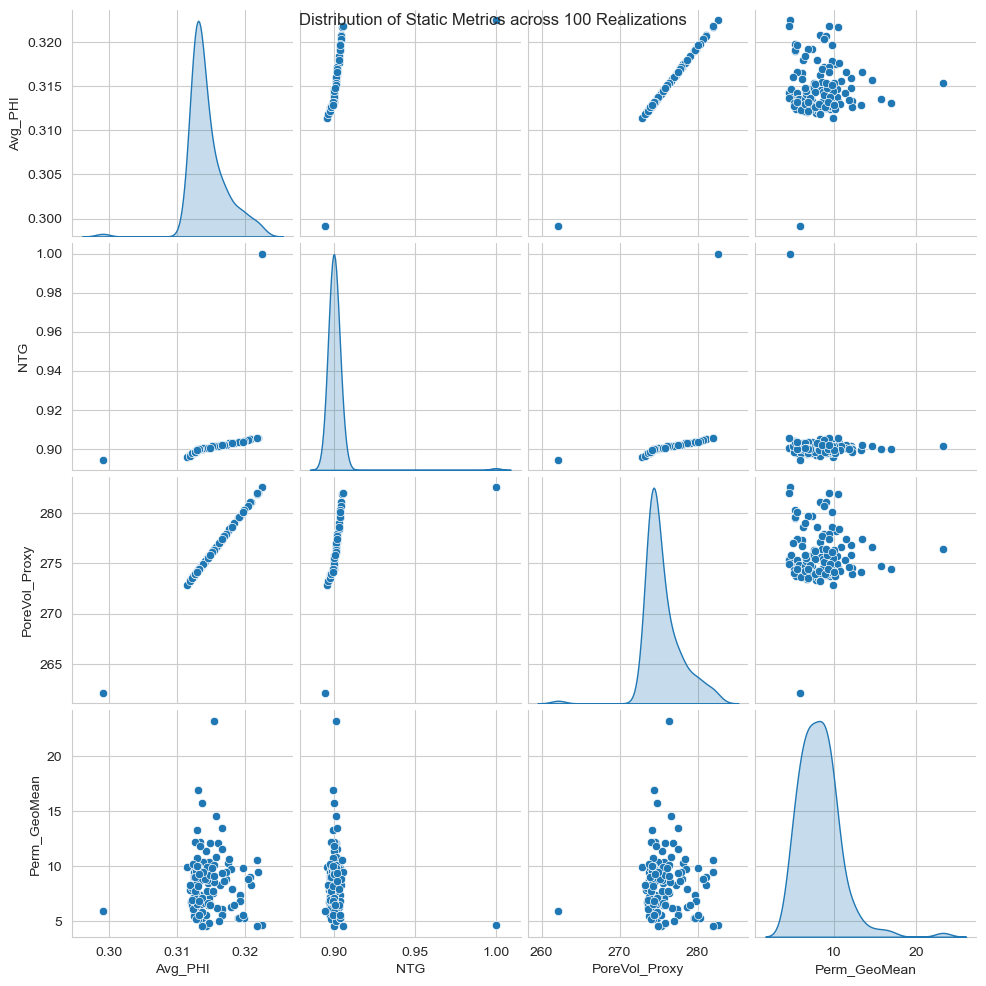

In [125]:
sns.pairplot(metrics_df, diag_kind='kde')
plt.suptitle('Distribution of Static Metrics across 100 Realizations')
plt.show()

## 7. Of the 100 models, select 8 representatives 

In [131]:
# 6. Select Representative Models (Clustering on Static Metrics)
scaler_metrics = StandardScaler()
metrics_scaled = scaler_metrics.fit_transform(metrics_df)   # this is a NumPy array!

kmeans_rep = KMeans(n_clusters=8, random_state=42, n_init=10)
metrics_df['Cluster'] = kmeans_rep.fit_predict(metrics_scaled)

# Select medoid (closest point to cluster center) for each cluster
representatives = []
for cluster in range(8):
    # IMPORTANT: index the scaled NUMPY ARRAY, not the scaler object
    cluster_mask = metrics_df['Cluster'] == cluster
    cluster_points_scaled = metrics_scaled[cluster_mask]          # ← correct: array[boolean_mask]
    
    center = kmeans_rep.cluster_centers_[cluster]
    
    # Find the point in this cluster closest to its own center
    distances = np.linalg.norm(cluster_points_scaled - center, axis=1)
    medoid_local_idx = distances.argmin()                        # index within this cluster
    
    # Convert back to original DataFrame index
    medoid_global_idx = metrics_df[cluster_mask].index[medoid_local_idx]
    
    representatives.append(medoid_global_idx)

print("Selected 8 representative realization indices:", representatives)

Selected 8 representative realization indices: [147, 107, 110, 46, 131, 10, 89, 149]


## 8. Quantifying uncertainty reduction

FULL ENSEMBLE (100 models):
P10 = 274
P50 = 275
P90 = 279

REPRESENTATIVE MODELS (8 models):
P10 = 271
P50 = 275
P90 = 281


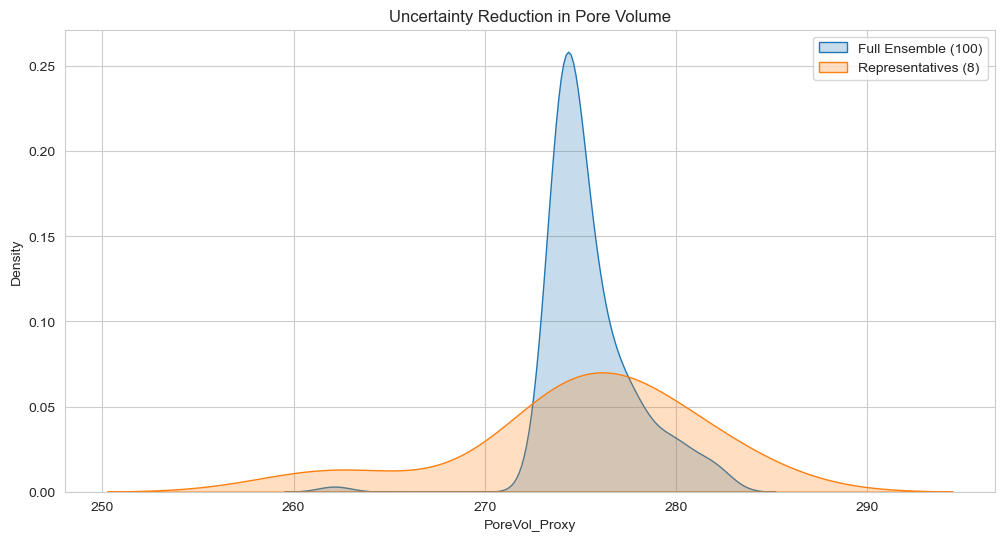

In [132]:
full_ensemble_pv = metrics_df['PoreVol_Proxy']
rep_pv = metrics_df.loc[representatives, 'PoreVol_Proxy']

print("FULL ENSEMBLE (100 models):")
print(f"P10 = {np.percentile(full_ensemble_pv, 10):.0f}")
print(f"P50 = {np.percentile(full_ensemble_pv, 50):.0f}")
print(f"P90 = {np.percentile(full_ensemble_pv, 90):.0f}")

print("\nREPRESENTATIVE MODELS (8 models):")
print(f"P10 = {np.percentile(rep_pv, 10):.0f}")
print(f"P50 = {np.percentile(rep_pv, 50):.0f}")
print(f"P90 = {np.percentile(rep_pv, 90):.0f}")

# Plot
plt.figure()
sns.kdeplot(full_ensemble_pv, label='Full Ensemble (100)', shade=True)
sns.kdeplot(rep_pv, label='Representatives (8)', shade=True)
plt.title('Uncertainty Reduction in Pore Volume')
plt.legend()
plt.show()

In [62]:
df.to_csv('well_with_petrophysics.csv', index=False)
metrics_df.to_csv('realizations_metrics.csv', index=False)